In [ ]:
#Referencia: https://www.kaggle.com/datasets/elemento/nyc-yellow-taxi-trip-data

import kagglehub

# Download latest version
path = kagglehub.dataset_download("elemento/nyc-yellow-taxi-trip-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\000010478\.cache\kagglehub\datasets\elemento\nyc-yellow-taxi-trip-data\versions\2


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Directorio donde están los CSV
directorio = Path(path)      # Cambia por tu ruta

# Lista de DataFrames
dfs = []

# Cargar todos los CSV
for archivo in directorio.glob("*.csv"):
    df = pd.read_csv(archivo)
    dfs.append(df)

print(f"Se cargaron {len(dfs)} archivos.")

Se cargaron 4 archivos.


In [3]:
data=pd.concat(dfs, ignore_index=True) #Se concatenan los dataframes para ser uno solo
data.sample(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,dropoff_latitude,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID
11231000,1,2015-01-29 08:57:57,2015-01-29 09:13:09,2,0.90,-73.968704,40.764420,1.0,N,-73.965790,40.755520,2,10.0,0.0,0.5,0.00,0.0,0.3,10.80,NaN
38806547,2,2016-03-08 17:42:30,2016-03-08 17:49:29,1,0.89,-73.972160,40.753220,NaN,N,-73.976082,40.744438,2,6.5,1.0,0.5,0.00,0.0,0.3,8.30,1.0
34036525,2,2016-02-24 13:19:31,2016-02-24 13:32:47,1,1.49,-73.998306,40.745251,NaN,N,-74.002815,40.760483,1,10.0,0.0,0.5,1.80,0.0,0.3,12.60,1.0
6430752,2,2015-01-07 15:03:03,2015-01-07 15:15:43,1,1.98,-73.983536,40.780949,1.0,N,-73.963417,40.771778,1,10.5,0.0,0.5,2.10,0.0,0.3,13.40,NaN
40874533,2,2016-03-18 20:41:32,2016-03-18 20:48:09,1,1.25,-73.981750,40.736729,NaN,N,-73.982452,40.723389,1,6.5,0.5,0.5,1.56,0.0,0.3,9.36,1.0
12896145,1,2016-01-01 03:42:16,2016-01-01 04:26:41,3,2.50,-74.008049,40.711655,NaN,N,-73.946556,40.712933,1,6.0,0.5,0.5,1.46,0.0,0.3,8.76,1.0
26101395,1,2016-02-06 23:50:21,2016-02-07 00:07:58,1,2.00,-74.001961,40.750751,NaN,N,-73.975891,40.734802,1,12.0,0.5,0.5,2.66,0.0,0.3,15.96,1.0
33685222,2,2016-02-22 19:25:22,2016-02-22 19:34:15,3,1.29,-74.002602,40.744740,NaN,N,-73.993660,40.732639,2,7.5,1.0,0.5,0.00,0.0,0.3,9.30,1.0
22353190,2,2016-01-05 07:04:07,2016-01-05 07:13:39,1,2.19,-73.981361,40.732979,NaN,N,-73.976074,40.757591,1,9.0,0.0,0.5,1.96,0.0,0.3,11.76,1.0
39144374,2,2016-03-14 16:52:37,2016-03-14 17:11:08,1,2.93,-74.001190,40.724171,NaN,N,-73.981888,40.758160,1,13.5,1.0,0.5,3.06,0.0,0.3,18.36,1.0


In [4]:
#Revisión de los datos para poder procesarlos
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 47248845 entries, 0 to 47248844
Data columns (total 20 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   str    
 2   tpep_dropoff_datetime  str    
 3   passenger_count        int64  
 4   trip_distance          float64
 5   pickup_longitude       float64
 6   pickup_latitude        float64
 7   RateCodeID             float64
 8   store_and_fwd_flag     str    
 9   dropoff_longitude      float64
 10  dropoff_latitude       float64
 11  payment_type           int64  
 12  fare_amount            float64
 13  extra                  float64
 14  mta_tax                float64
 15  tip_amount             float64
 16  tolls_amount           float64
 17  improvement_surcharge  float64
 18  total_amount           float64
 19  RatecodeID             float64
dtypes: float64(14), int64(3), str(3)
memory usage: 8.8 GB


In [5]:
#Vamos a convertir las fechas y extraer información como día de la semana, hora del día y mes del año. Esto nos permitirá analizar los datos de manera más efectiva.
data["tpep_pickup_datetime"] = pd.to_datetime(data["tpep_pickup_datetime"])
data["tpep_dropoff_datetime"] = pd.to_datetime(data["tpep_dropoff_datetime"])
data["day_of_week"] = data["tpep_pickup_datetime"].dt.dayofweek
data["hour_of_day"] = data["tpep_pickup_datetime"].dt.hour
data["month"] = data["tpep_pickup_datetime"].dt.month
data.sample(10)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,store_and_fwd_flag,dropoff_longitude,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month
40294461,2,2016-03-17 14:16:34,2016-03-17 14:18:26,2,0.73,-73.946175,40.801022,NaN,N,-73.952545,...,0.0,0.5,0.00,0.0,0.3,4.80,1.0,3,14,3
34773088,2,2016-02-27 18:46:14,2016-02-27 18:55:47,1,1.36,-73.961601,40.811340,NaN,N,-73.955566,...,0.0,0.5,2.32,0.0,0.3,11.62,1.0,5,18,2
21192614,1,2016-01-21 08:42:36,2016-01-21 08:48:46,1,1.10,-73.979317,40.766289,NaN,N,-73.983910,...,0.0,0.5,1.35,0.0,0.3,8.15,1.0,3,8,1
9498746,1,2015-01-22 15:34:09,2015-01-22 15:38:04,2,0.90,-73.955521,40.773628,1.0,N,-73.945435,...,0.0,0.5,1.15,0.0,0.3,6.95,NaN,3,15,1
33463394,1,2016-02-29 19:16:57,2016-02-29 19:31:55,1,3.60,-73.984924,40.747841,NaN,N,-73.975861,...,1.0,0.5,0.00,0.0,0.3,15.30,1.0,0,19,2
14599017,1,2016-01-09 12:03:02,2016-01-09 12:11:17,1,1.10,-74.015305,40.711937,NaN,N,-74.004608,...,0.0,0.5,1.65,0.0,0.3,9.95,1.0,5,12,1
16240905,1,2016-01-18 12:04:56,2016-01-18 12:20:24,2,3.40,-74.017342,40.707214,NaN,Y,-74.008217,...,0.0,0.5,3.70,0.0,0.3,18.50,1.0,0,12,1
18406280,1,2016-01-17 17:16:49,2016-01-17 17:31:52,2,1.40,-73.984703,40.736816,NaN,N,-74.000626,...,0.0,0.5,2.00,0.0,0.3,13.30,1.0,6,17,1
9011351,2,2015-01-13 08:21:26,2015-01-13 08:49:33,1,4.47,-73.955170,40.779385,1.0,N,-73.981079,...,0.0,0.5,0.00,0.0,0.3,20.80,NaN,1,8,1
43116400,1,2016-03-24 08:37:46,2016-03-24 08:59:52,1,2.70,-73.991020,40.734848,NaN,N,-73.995796,...,0.0,0.5,0.00,0.0,0.3,16.30,1.0,3,8,3


In [6]:
#Campo de duración del viaje
data["trip_duration"] = (data["tpep_dropoff_datetime"] - data["tpep_pickup_datetime"]).dt.total_seconds() / 60  # Duración en minutos
data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month,trip_duration
count,4.724884e+07,47248845,47248845,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,1.274899e+07,4.724884e+07,4.724884e+07,...,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,3.449986e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,1.529570e+00,2015-11-01 19:34:22.551143,2015-11-01 19:49:31.111697,1.667040e+00,7.508418e+00,-7.276452e+01,4.008470e+01,1.036901e+00,-7.282501e+01,4.011889e+01,...,4.977081e-01,1.794568e+00,2.843674e-01,2.952466e-01,1.559273e+01,1.039150e+00,3.100029e+00,1.362430e+01,1.757774e+00,1.514268e+01
min,1.000000e+00,2015-01-01 00:00:00,2015-01-01 00:00:00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-7.401667e+02,-7.703949e+01,...,-1.000000e+00,-2.208000e+02,-9.999000e+01,-3.000000e-01,-9.584000e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.371001e+05
25%,1.000000e+00,2015-01-30 07:34:06,2015-01-30 07:47:19,1.000000e+00,1.000000e+00,-7.399166e+01,4.073611e+01,1.000000e+00,-7.399120e+01,4.073459e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,1.000000e+00,1.000000e+00,9.000000e+00,1.000000e+00,6.316667e+00
50%,2.000000e+00,2016-01-31 21:20:27,2016-01-31 21:35:50,1.000000e+00,1.690000e+00,-7.398155e+01,4.075335e+01,1.000000e+00,-7.397962e+01,4.075380e+01,...,5.000000e-01,1.250000e+00,0.000000e+00,3.000000e-01,1.160000e+01,1.000000e+00,3.000000e+00,1.400000e+01,1.000000e+00,1.045000e+01
75%,2.000000e+00,2016-03-02 05:54:00,2016-03-02 06:08:11,2.000000e+00,3.090000e+00,-7.396657e+01,4.076779e+01,1.000000e+00,-7.396225e+01,4.076920e+01,...,5.000000e-01,2.260000e+00,0.000000e+00,3.000000e-01,1.715000e+01,1.000000e+00,5.000000e+00,1.900000e+01,3.000000e+00,1.678333e+01
max,2.000000e+00,2016-03-31 23:59:59,2016-06-29 15:58:16,9.000000e+00,1.907263e+07,9.464387e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,...,8.970000e+01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+00,5.485556e+05
std,4.991248e-01,NaN,NaN,1.322092e+00,6.487658e+03,9.381830e+00,5.168528e+00,6.732240e-01,9.150215e+00,5.040345e+00,...,4.672388e-02,5.747384e+02,1.657184e+00,3.812080e-02,5.801393e+02,5.564537e-01,1.927974e+00,6.370660e+00,8.369175e-01,3.790111e+02


In [7]:
#Miremos las características del df para ver qué necesitamos filtrar. 
data.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,pickup_longitude,pickup_latitude,RateCodeID,dropoff_longitude,dropoff_latitude,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,RatecodeID,day_of_week,hour_of_day,month,trip_duration
count,4.724884e+07,47248845,47248845,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,1.274899e+07,4.724884e+07,4.724884e+07,...,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07,3.449986e+07,4.724884e+07,4.724884e+07,4.724884e+07,4.724884e+07
mean,1.529570e+00,2015-11-01 19:34:22.551143,2015-11-01 19:49:31.111697,1.667040e+00,7.508418e+00,-7.276452e+01,4.008470e+01,1.036901e+00,-7.282501e+01,4.011889e+01,...,4.977081e-01,1.794568e+00,2.843674e-01,2.952466e-01,1.559273e+01,1.039150e+00,3.100029e+00,1.362430e+01,1.757774e+00,1.514268e+01
min,1.000000e+00,2015-01-01 00:00:00,2015-01-01 00:00:00,0.000000e+00,-3.390584e+06,-1.616987e+02,-7.703949e+01,1.000000e+00,-7.401667e+02,-7.703949e+01,...,-1.000000e+00,-2.208000e+02,-9.999000e+01,-3.000000e-01,-9.584000e+02,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,-5.371001e+05
25%,1.000000e+00,2015-01-30 07:34:06,2015-01-30 07:47:19,1.000000e+00,1.000000e+00,-7.399166e+01,4.073611e+01,1.000000e+00,-7.399120e+01,4.073459e+01,...,5.000000e-01,0.000000e+00,0.000000e+00,3.000000e-01,8.300000e+00,1.000000e+00,1.000000e+00,9.000000e+00,1.000000e+00,6.316667e+00
50%,2.000000e+00,2016-01-31 21:20:27,2016-01-31 21:35:50,1.000000e+00,1.690000e+00,-7.398155e+01,4.075335e+01,1.000000e+00,-7.397962e+01,4.075380e+01,...,5.000000e-01,1.250000e+00,0.000000e+00,3.000000e-01,1.160000e+01,1.000000e+00,3.000000e+00,1.400000e+01,1.000000e+00,1.045000e+01
75%,2.000000e+00,2016-03-02 05:54:00,2016-03-02 06:08:11,2.000000e+00,3.090000e+00,-7.396657e+01,4.076779e+01,1.000000e+00,-7.396225e+01,4.076920e+01,...,5.000000e-01,2.260000e+00,0.000000e+00,3.000000e-01,1.715000e+01,1.000000e+00,5.000000e+00,1.900000e+01,3.000000e+00,1.678333e+01
max,2.000000e+00,2016-03-31 23:59:59,2016-06-29 15:58:16,9.000000e+00,1.907263e+07,9.464387e+01,4.047000e+02,9.900000e+01,8.527402e+01,4.595333e+02,...,8.970000e+01,3.950589e+06,1.450090e+03,3.000000e-01,3.950612e+06,9.900000e+01,6.000000e+00,2.300000e+01,3.000000e+00,5.485556e+05
std,4.991248e-01,NaN,NaN,1.322092e+00,6.487658e+03,9.381830e+00,5.168528e+00,6.732240e-01,9.150215e+00,5.040345e+00,...,4.672388e-02,5.747384e+02,1.657184e+00,3.812080e-02,5.801393e+02,5.564537e-01,1.927974e+00,6.370660e+00,8.369175e-01,3.790111e+02


In [8]:
#Organización de los datos para poder analizarlos mejor. Eliminamos columnas que no nos interesan y filtramos los datos para que tengan sentido.
eliminar=['VendorID','store_and_fwd_flag','RatecodeID']
minimo={'passenger_count':1,'trip_distance':0.1,'fare_amount':0.1,'tip_amount':0.0,'tolls_amount':0.0,'total_amount':0.1}
maximo={'trip_distance':200,'fare_amount':500,'tip_amount':100,'tolls_amount':100,'total_amount':500}
data=data.drop(columns=eliminar)
for col, min_val in minimo.items():
    data = data[data[col] >= min_val]
for col, max_val in maximo.items():
    data = data[data[col] <= max_val]


Text(0.5, 1.0, 'Distribución del pago de los viajes')

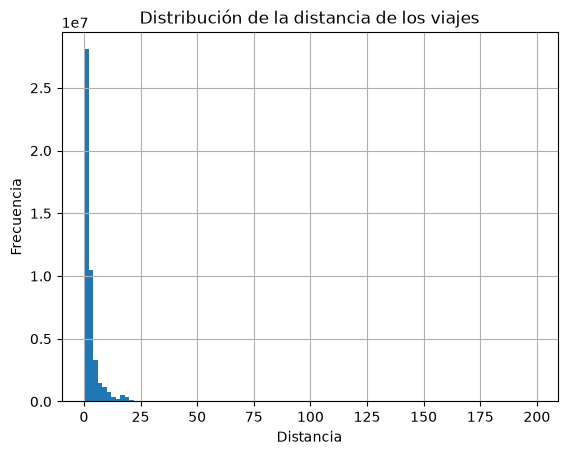

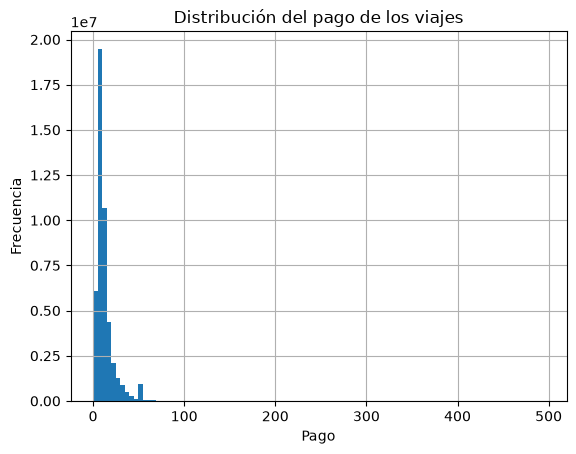

In [9]:
#Análisis de la distancia de los viajes. Vamos a ver cómo se distribuyen las distancias de los viajes en el dataset.
data['trip_distance'].hist(bins=100)
plt.title('Distribución de la distancia de los viajes')
plt.xlabel('Distancia')
plt.ylabel('Frecuencia')
#Análisis del pago de los viajes. Vamos a ver cómo se distribuyen los pagos de los viajes en el dataset.
plt.figure()
data['fare_amount'].hist(bins=100)
plt.xlabel('Pago')
plt.ylabel('Frecuencia')
plt.title('Distribución del pago de los viajes')

In [10]:
#Miremos qué relaciones pueden aparecer entre los pagos y las distancias
import plotly.express as px
px.scatter(x='trip_distance', y='fare_amount', data_frame=data.sample(100000), color='month', size='total_amount', hover_data=['passenger_count', 'payment_type'], title='Relación entre distancia y duración del viaje')

passenger_count
1    7.094137e-01
2    1.424150e-01
3    4.056227e-02
4    1.931954e-02
5    5.415242e-02
6    3.413498e-02
7    7.038946e-07
8    6.825644e-07
9    7.038946e-07
Name: count, dtype: float64


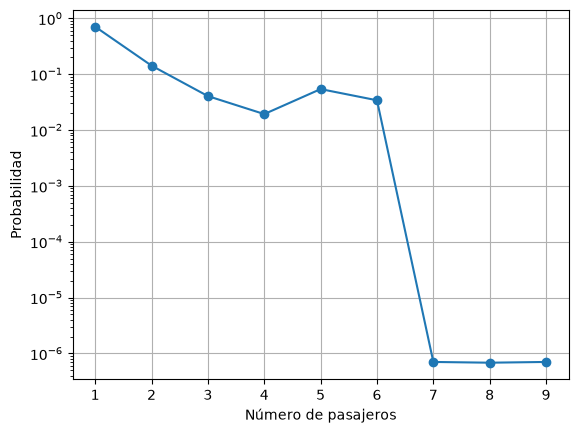

In [11]:
#Hagamos el análisis de probabilidad del número de pasajeros. Vamos a ver cómo se distribuye el número de pasajeros en los viajes del dataset.
cnt=data['passenger_count'].value_counts().sort_index()
pr=cnt/cnt.sum()
plt.semilogy(pr.index, pr.values, marker='o')
plt.ylabel('Probabilidad')
plt.xlabel('Número de pasajeros')
plt.grid()
print(pr)

Probabilidad de no pagar paeajes: 0.9521605084422556
Probabilidad de pagar $0.01 en peajes: 0.0017
Probabilidad de pagar $2.51 en peajes: 0.0032
Probabilidad de pagar $5.01 en peajes: 0.3743
Probabilidad de pagar $7.51 en peajes: 0.0018
Probabilidad de pagar $10.01 en peajes: 0.0111
Probabilidad de pagar $12.51 en peajes: 0.0015
Probabilidad de pagar $15.01 en peajes: 0.0038
Probabilidad de pagar $17.51 en peajes: 0.0016
Probabilidad de pagar $20.01 en peajes: 0.0005
Probabilidad de pagar $22.51 en peajes: 0.0003
Probabilidad de pagar $25.01 en peajes: 0.0001
Probabilidad de pagar $27.51 en peajes: 0.0001
Probabilidad de pagar $30.01 en peajes: 0.0000


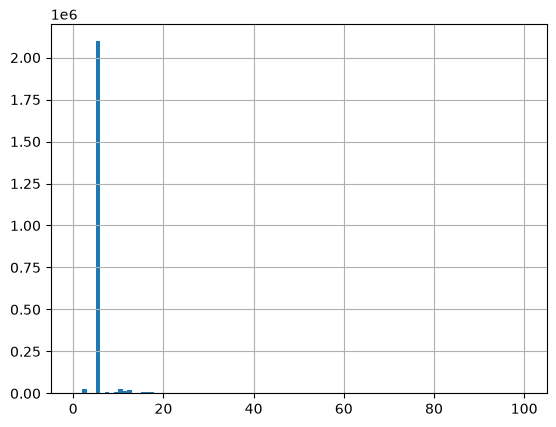

In [15]:
#Hagamos el análisis de probabilidad del valor pagado en peajes en la ruta
print('Probabilidad de no pagar paeajes:', len((data[data['tolls_amount']==0])) / len(data))
cnt=data[data['tolls_amount']>0]['tolls_amount'].hist(bins=100)
pr, bins=np.histogram(data[data['tolls_amount']>0]['tolls_amount'], bins=40, density=True)
for pi, bi in zip(pr, bins):
    if(bi<=32):
        print(f'Probabilidad de pagar ${bi:.2f} en peajes: {pi:.4f}')

In [16]:
#Observe que los datos del dataframe tienen mucha información. 
#La función de la estadística descriptiva nos da una idea de la distribución de los datos
# a nive univariable y de la relación entre las variables a nivel multivariable
data.info()

<class 'pandas.DataFrame'>
Index: 46882020 entries, 0 to 47248844
Data columns (total 21 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        int64         
 3   trip_distance          float64       
 4   pickup_longitude       float64       
 5   pickup_latitude        float64       
 6   RateCodeID             float64       
 7   dropoff_longitude      float64       
 8   dropoff_latitude       float64       
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  day_of_week            int32         
 18  hour_of_day            int32        

In [ ]:
#Por favor piense en otras relaciones, hipótesis que quiera validar dentro de los datos
#y realice los análisis correspondientes. Por ejemplo, puede analizar la relación entre el día de la semana y la hora del día con el número de pasajeros, la distancia del viaje y el pago total. También puede explorar cómo varían los pagos de peajes según la distancia del viaje o el número de pasajeros.
